# Trading Strategies Performance Analysis

This notebook analyzes the equity curves of various trading strategies over an 8-year and 3-month backtest period. The performance is normalized to a base of 100 and compared against the S&P 500 benchmark.

In [2]:
import json
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep", context="notebook", rc={"axes.titlesize": 16, "axes.labelsize": 12, "lines.linewidth": 2.5})
from datetime import datetime
import pandas as pd
import yfinance as yf
import glob
import os

def get_equity_df(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    equity_series = data['charts']['Strategy Equity']['series']['Equity']['values']
    dates = []
    values = []
    
    for point in equity_series:
        if isinstance(point, dict) and 'x' in point and 'y' in point:
            timestamp = point['x']
            val = point['y']
        elif isinstance(point, list) and len(point) >= 2:
            timestamp = point[0]
            val = point[1]
        else:
            continue
            
        if timestamp > 1e11:
            timestamp /= 1000.0
            
        dates.append(datetime.fromtimestamp(timestamp))
        values.append(val)
        
    df = pd.DataFrame({'Date': dates, 'Equity': values})
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    df = df.resample('D').last().dropna()
    df.index = df.index.tz_localize(None)
    return df

def plot_equities(period_suffix, title):
    files = glob.glob(f"stats/*_{period_suffix}.json")
    files.sort()
    
    if not files:
        print(f"No files found for {period_suffix}")
        return
        
    dfs = {}
    for f in files:
        strat_name = os.path.basename(f).split('_')[0]
        dfs[strat_name] = get_equity_df(f)
        
    # Note: strategy 3 8y is missing in stats folder
    min_date = min([df.index.min() for df in dfs.values()])
    max_date = max([df.index.max() for df in dfs.values()])
    
    sp500 = yf.download('^GSPC', start=min_date.strftime('%Y-%m-%d'), end=max_date.strftime('%Y-%m-%d'))
    if isinstance(sp500.columns, pd.MultiIndex):
        sp500_close = sp500['Close']['^GSPC']
    else:
        sp500_close = sp500['Close']
        
    df_sp500 = pd.DataFrame({'SP500': sp500_close})
    df_sp500.index = df_sp500.index.tz_localize(None)
    
    plt.figure(figsize=(14, 7))
    
    # Plot S&P 500
    df_sp500_norm = df_sp500.loc[min_date:max_date]
    if not df_sp500_norm.empty:
        norm_sp500 = (df_sp500_norm['SP500'] / df_sp500_norm['SP500'].iloc[0]) * 100
        plt.plot(df_sp500_norm.index, norm_sp500, label='S&P 500', color='gray', linewidth=3, linestyle='--', alpha=0.7)
        plt.fill_between(df_sp500_norm.index, norm_sp500, 100, where=(norm_sp500 > 100), color='gray', alpha=0.1)
        plt.fill_between(df_sp500_norm.index, norm_sp500, 100, where=(norm_sp500 <= 100), color='gray', alpha=0.1)
    
    # Plot Strategies
    for strat_name, df in dfs.items():
        # Normalize based on strictly overlapping periods with S&P500 for fairness
        df_merged = df.join(df_sp500, how='inner').ffill()
        if not df_merged.empty:
            norm_strat = (df_merged['Equity'] / df_merged['Equity'].iloc[0]) * 100
            plt.plot(df_merged.index, norm_strat, label=f'{strat_name.capitalize()} Equity', alpha=0.85)
        
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Normalized Equity (Base 100)')
    plt.grid(True)
    plt.legend(frameon=True, facecolor="white", framealpha=0.9, edgecolor="gray", fancybox=True, loc="upper left")
    plt.tight_layout()
    plt.show()


## 8-Year Backtest Comparison

> Note: `strat3_8y.json` is missing from the data directory. The plotting cell will graph all 8y JSONs it finds.

[*********************100%***********************]  1 of 1 completed


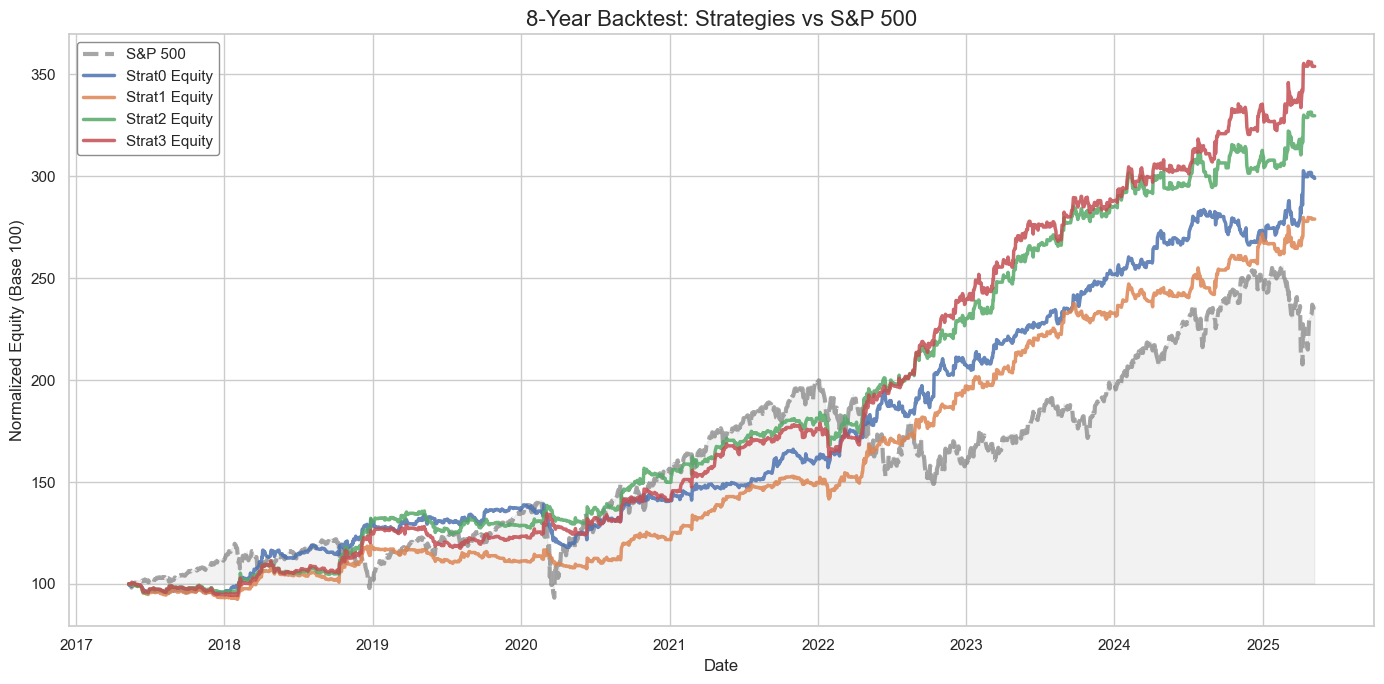

In [3]:
plot_equities('8y', '8-Year Backtest: Strategies vs S&P 500')

## 3-Month Backtest Comparison

Contains 0, 1, 2, and 3.

[*********************100%***********************]  1 of 1 completed


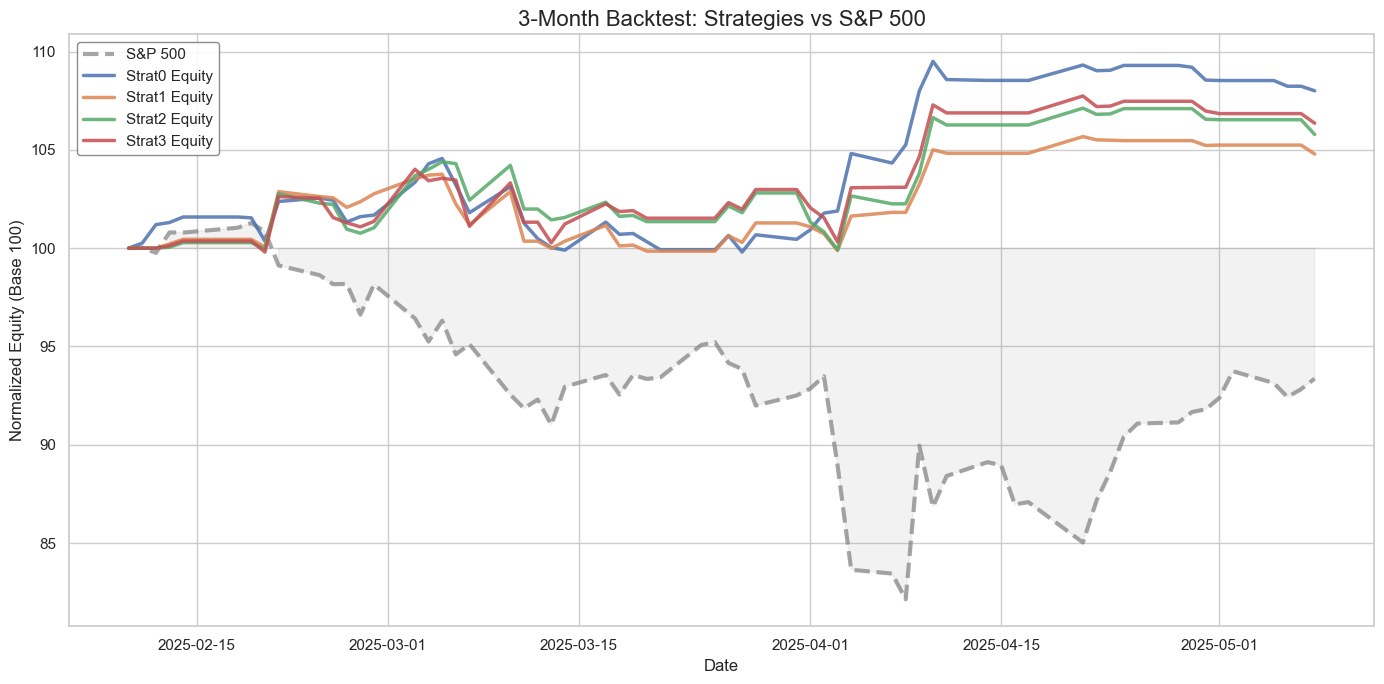

In [4]:
plot_equities('3m', '3-Month Backtest: Strategies vs S&P 500')